## Imports

In [85]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
import random
import pandas as pd

## Part 1

In [86]:
n = 100

def generate_circle_points(n):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = np.cos(angles)
    y = np.sin(angles)
    return np.column_stack((x, y))

def generate_random_points(n):
    return np.random.uniform(0, 1, size=(n, 2))

def euclidean_dist(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))


def route_cost(route, points):
    total = 0

    for i in range(len(route) - 1):
        total += euclidean_dist(points[route[i]], points[route[i + 1]])

    # return to the starting city
    total += euclidean_dist(points[route[-1]], points[route[0]])

    return total


def propose_swap(route):
    new_route = route.copy()

    i = np.random.randint(0, len(route))
    j = np.random.randint(0, len(route))

    while i == j:
        j = np.random.randint(0, len(route))

    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route

def cooling_sqrt(k):
    return 1 / np.sqrt(1 + k)


def cooling_log(k):
    return 1 / np.log(2 + k)    

    


In [87]:
def simulated_annealing(points, iterations=10000, cooling_function=cooling_log):
    n = len(points)

    current_route = list(range(n))
    np.random.shuffle(current_route)

    current_cost = route_cost(current_route, points)

    best_route = current_route.copy()
    best_cost = current_cost

    cost_history = []

    for k in range(iterations):
        T = cooling_function(k)

        proposed_route = propose_swap(current_route)
        proposed_cost = route_cost(proposed_route, points)

        if proposed_cost <= current_cost:
            current_route = proposed_route
            current_cost = proposed_cost
        else:
            acceptance_probability = np.exp(-(proposed_cost - current_cost) / T)

            if np.random.uniform(0, 1) < acceptance_probability:
                current_route = proposed_route
                current_cost = proposed_cost

        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        cost_history.append(best_cost)

    return best_route, best_cost, cost_history

In [88]:
def plot_route(points, route, title="Route"):
    ordered_points = points[route]

    # add first point at the end to close the route
    closed_route = np.vstack([ordered_points, ordered_points[0]])

    plt.plot(closed_route[:, 0], closed_route[:, 1], marker="o")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.show()

Best cost: 13.207699740690297
Best route: [6, 7, 8, 9, 10, 11, 13, 15, 19, 20, 23, 24, 21, 22, 28, 0, 1, 29, 27, 25, 26, 18, 17, 16, 14, 12, 3, 2, 4, 5]


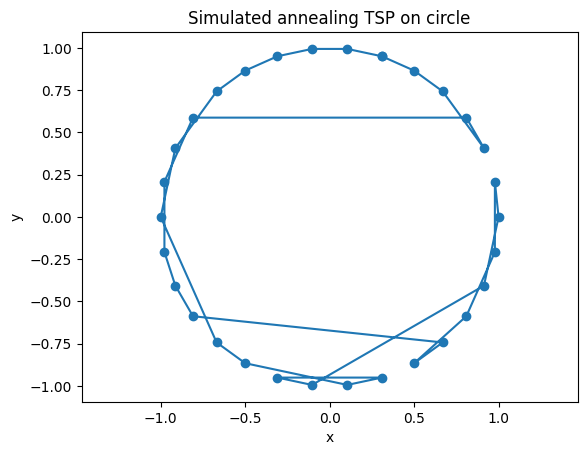

Best cost: 10.892153902492183
Best route: [3, 2, 1, 0, 29, 28, 27, 6, 8, 10, 11, 12, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 9, 7, 5, 4]


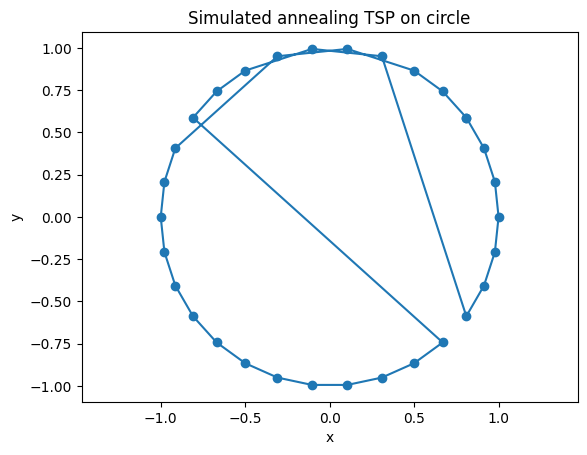

Best cost: 6.2717077960592045
Best route: [29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


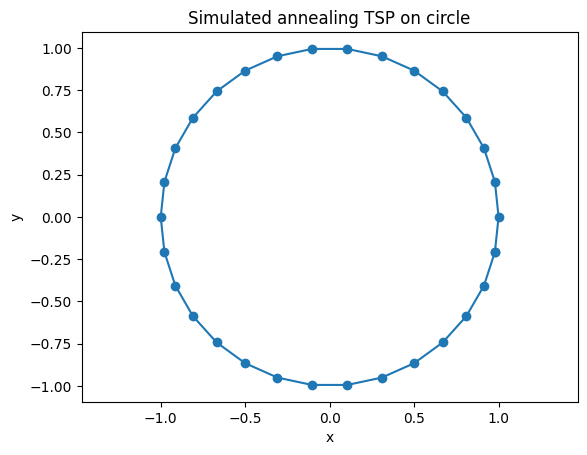

In [89]:
n = 30
points = generate_circle_points(n)

best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=1000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP on circle")

points = generate_circle_points(n)



best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=10000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP on circle")


points = generate_circle_points(n)

best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=20000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP on circle")

Best cost: 6.260461581998286
Best route: [23, 28, 26, 2, 8, 18, 9, 25, 13, 19, 12, 4, 7, 5, 16, 21, 17, 14, 10, 22, 11, 3, 1, 15, 0, 24, 29, 20, 6, 27]


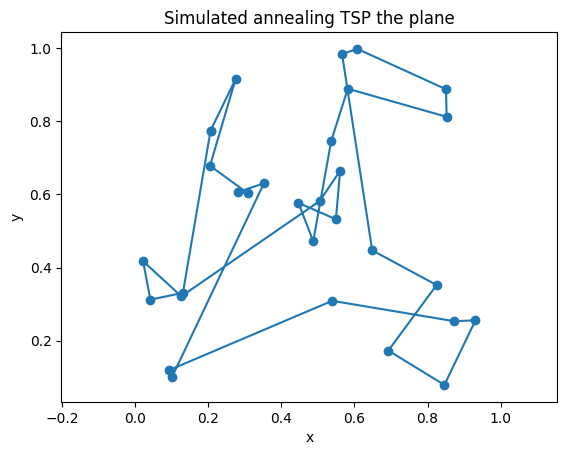

Best cost: 4.946753187384295
Best route: [16, 20, 10, 19, 18, 12, 3, 6, 0, 24, 27, 4, 15, 21, 8, 25, 13, 5, 22, 14, 23, 7, 9, 11, 17, 28, 26, 29, 1, 2]


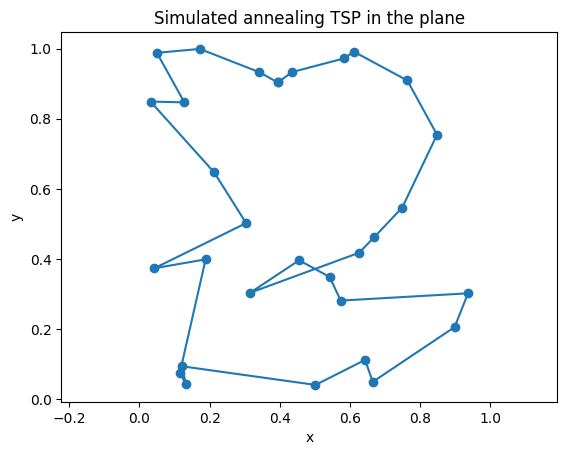

Best cost: 5.877377716341946
Best route: [3, 13, 26, 2, 9, 16, 28, 11, 22, 25, 1, 6, 29, 7, 19, 8, 23, 21, 17, 14, 0, 20, 18, 24, 15, 12, 5, 27, 10, 4]


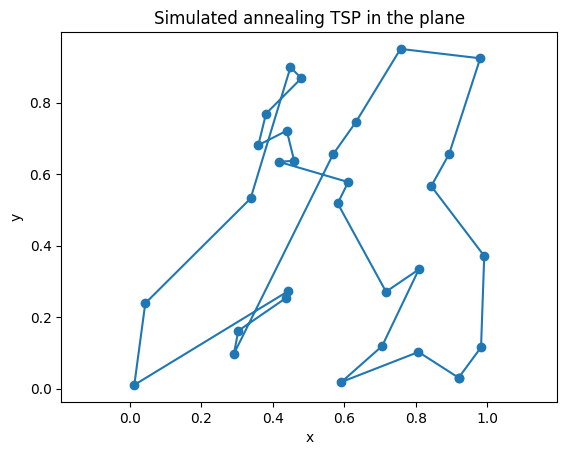

In [90]:
n = 30
points = generate_random_points(n)

best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=1000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP the plane")

points = generate_random_points(n)



best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=10000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP in the plane")


points = generate_random_points(n)

best_route, best_cost, cost_history = simulated_annealing(
    points,
    iterations=20000,
    cooling_function=cooling_log
)

print("Best cost:", best_cost)
print("Best route:", best_route)

plot_route(points, best_route, "Simulated annealing TSP in the plane")

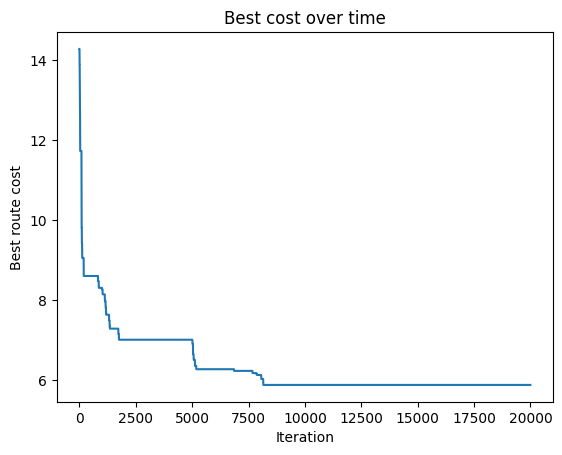

In [91]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Best route cost")
plt.title("Best cost over time")
plt.show()

### Part 2

In [93]:
cost_matrix = np.loadtxt(open("cost(1).csv","rb"), delimiter=",")

In [94]:
def read_cost_matrix(filename):
    raw = pd.read_excel(filename, header=None)

    # If the file has one column where each row is a comma-separated string
    if raw.shape[1] == 1:
        matrix = raw[0].str.split(",", expand=True).astype(float).values
    else:
        matrix = raw.astype(float).values

    return matrix

In [95]:
if False:
    cost_matrix = np.array([
        [0, 225, 110, 8, 257, 22, 83, 231, 277, 243, 94, 30, 4, 265, 274, 250, 87, 83, 271, 86],
        [255, 0, 265, 248, 103, 280, 236, 91, 3, 87, 274, 265, 236, 8, 24, 95, 247, 259, 28, 259],
        [87, 236, 0, 95, 248, 110, 25, 274, 250, 271, 9, 244, 83, 250, 248, 280, 29, 26, 239, 7],
        [8, 280, 83, 0, 236, 28, 91, 239, 280, 259, 103, 23, 6, 280, 244, 259, 95, 87, 230, 84],
        [268, 87, 239, 271, 0, 244, 275, 9, 84, 25, 244, 239, 275, 83, 110, 24, 274, 280, 84, 274],
        [21, 265, 99, 29, 259, 0, 99, 230, 265, 271, 87, 5, 22, 239, 236, 250, 87, 95, 271, 91],
        [95, 236, 28, 91, 247, 93, 0, 247, 259, 244, 27, 91, 87, 268, 275, 280, 7, 8, 240, 27],
        [280, 83, 250, 261, 4, 239, 230, 0, 103, 24, 239, 261, 271, 95, 87, 21, 274, 255, 110, 280],
        [247, 9, 280, 274, 84, 255, 259, 99, 0, 87, 255, 274, 280, 3, 27, 83, 259, 244, 28, 274],
        [230, 103, 268, 275, 23, 244, 264, 28, 83, 0, 268, 275, 261, 91, 95, 8, 277, 261, 84, 247],
        [87, 239, 9, 103, 261, 110, 29, 255, 239, 261, 0, 259, 84, 239, 261, 242, 24, 25, 242, 5],
        [30, 255, 95, 30, 247, 4, 87, 274, 242, 255, 99, 0, 24, 280, 274, 259, 91, 83, 247, 91],
        [8, 261, 83, 6, 255, 29, 103, 261, 247, 242, 110, 29, 0, 261, 244, 230, 87, 84, 280, 100],
        [242, 8, 259, 280, 99, 242, 244, 99, 3, 84, 280, 236, 259, 0, 27, 95, 274, 261, 24, 268],
        [274, 22, 250, 236, 83, 261, 247, 103, 22, 91, 250, 236, 261, 25, 0, 103, 255, 261, 5, 247],
        [244, 91, 261, 255, 28, 236, 261, 29, 103, 9, 242, 261, 244, 87, 110, 0, 242, 236, 95, 259],
        [84, 236, 27, 99, 230, 83, 7, 259, 230, 230, 22, 87, 93, 250, 255, 247, 0, 9, 259, 24],
        [91, 242, 28, 87, 250, 110, 6, 271, 271, 255, 27, 103, 84, 250, 271, 244, 5, 0, 271, 29],
        [261, 24, 250, 271, 84, 255, 261, 87, 28, 110, 250, 248, 248, 22, 3, 103, 271, 248, 0, 236],
        [103, 271, 8, 91, 255, 91, 21, 271, 236, 271, 7, 250, 83, 247, 250, 271, 22, 27, 248, 0]
    ])
    

#print(cost_matrix.shape)
#print(cost_matrix)

In [96]:
def route_cost_matrix(route, cost_matrix):
    total = 0

    for i in range(len(route) - 1):
        total += cost_matrix[route[i], route[i + 1]]

    # return to start
    total += cost_matrix[route[-1], route[0]]

    return total

In [97]:
def simulated_annealing_matrix(cost_matrix, iterations=50000, cooling_function=cooling_log,):
    n = len(cost_matrix)

    current_route = list(range(n))
    np.random.shuffle(current_route)

    current_cost = route_cost_matrix(current_route, cost_matrix)

    best_route = current_route.copy()
    best_cost = current_cost

    cost_history = []

    for k in range(iterations):
        T = cooling_function(k)

        proposed_route = propose_swap(current_route)
        proposed_cost = route_cost_matrix(proposed_route, cost_matrix)

        if proposed_cost <= current_cost:
            current_route = proposed_route
            current_cost = proposed_cost
        else:
            acceptance_probability = np.exp(-(proposed_cost - current_cost) / T)

            if np.random.uniform(0, 1) < acceptance_probability:
                current_route = proposed_route
                current_cost = proposed_cost

        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        cost_history.append(best_cost)

    return best_route, best_cost, cost_history

In [104]:
best_best_cost = 9999999
best_best_route = []
best_cost_history = []
for i in range (20):
    best_route, best_cost, cost_history = simulated_annealing_matrix(
        cost_matrix,
        iterations=50000,
        cooling_function=cooling_sqrt
    )
    if best_cost < best_best_cost:
        best_best_cost = best_cost
        best_best_route = best_route
        best_cost_history = cost_history


print("Best route:", best_best_route)
print("Best cost:", best_best_cost)

Best route: [9, 0, 12, 3, 5, 11, 17, 6, 16, 10, 2, 19, 8, 13, 1, 14, 18, 4, 7, 15]
Best cost: 806.0


In [105]:
print("Best route using town labels:")
print([x + 1 for x in best_best_route])

print("Best cost:", best_best_cost)

Best route using town labels:
[10, 1, 13, 4, 6, 12, 18, 7, 17, 11, 3, 20, 9, 14, 2, 15, 19, 5, 8, 16]
Best cost: 806.0


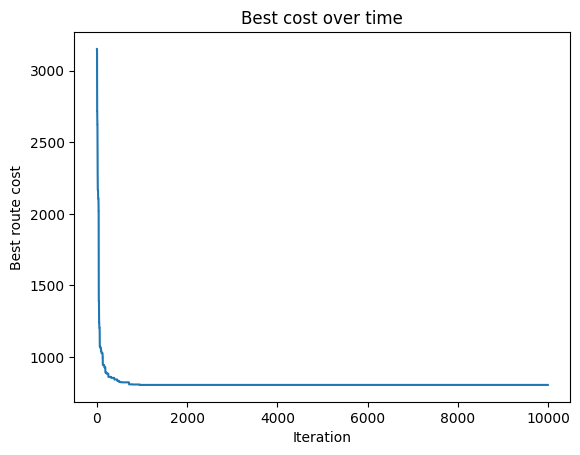

In [ ]:
x_range = 3000
x = [i for i in range(0, x_range)]
plt.plot(x, best_cost_history[0:x_range])
plt.xlabel("Iteration")
plt.ylabel("Best route cost")
plt.title("Best cost over time")
plt.show()

In [ ]:
route_log, cost_log, history_log = simulated_annealing_matrix(cost_matrix,iterations=50000,cooling_function=cooling_log)

route_sqrt, cost_sqrt, history_sqrt = simulated_annealing_matrix(cost_matrix,iterations=50000,cooling_function=cooling_sqrt)

print("Log cooling best cost:", cost_log)
print("Log cooling route:", [x + 1 for x in route_log])

print()

print("Sqrt cooling best cost:", cost_sqrt)
print("Sqrt cooling route:", [x + 1 for x in route_sqrt])

Log cooling best cost: 1094
Log cooling route: [8, 7, 18, 17, 11, 20, 3, 19, 15, 2, 9, 14, 12, 6, 1, 4, 13, 16, 10, 5]

Sqrt cooling best cost: 1310
Sqrt cooling route: [15, 5, 8, 16, 10, 1, 13, 4, 18, 7, 17, 11, 2, 9, 14, 12, 6, 20, 3, 19]


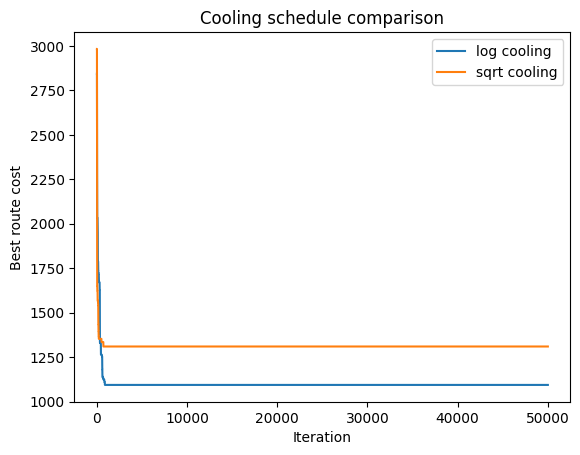

In [ ]:
plt.plot(history_log, label="log cooling")
plt.plot(history_sqrt, label="sqrt cooling")
plt.xlabel("Iteration")
plt.ylabel("Best route cost")
plt.title("Cooling schedule comparison")
plt.legend()
plt.show()

### Run repeated

In [ ]:
def repeated_runs(cost_matrix, cooling_function, runs=20, iterations=50000):
    best_costs = []
    best_routes = []

    for r in range(runs):
        route, cost, history = simulated_annealing_matrix(cost_matrix,iterations=iterations,cooling_function=cooling_function)
        best_costs.append(cost)
        best_routes.append(route)

    best_index = np.argmin(best_costs)

    return best_routes[best_index], best_costs[best_index], best_costs

In [ ]:
best_route_log, best_cost_log, costs_log = repeated_runs(
    cost_matrix,
    cooling_log,
    runs=20,
    iterations=50000
)

best_route_sqrt, best_cost_sqrt, costs_sqrt = repeated_runs(
    cost_matrix,
    cooling_sqrt,
    runs=20,
    iterations=50000
)

print("Log cooling:")
print("Best cost:", best_cost_log)
print("Best route:", [x + 1 for x in best_route_log])
print("Average cost:", np.mean(costs_log))

print()

print("Sqrt cooling:")
print("Best cost:", best_cost_sqrt)
print("Best route:", [x + 1 for x in best_route_sqrt])
print("Average cost:", np.mean(costs_sqrt))

Log cooling:
Best cost: 880
Best route: [5, 8, 16, 10, 19, 15, 4, 1, 13, 12, 6, 17, 18, 7, 11, 20, 3, 2, 14, 9]
Average cost: 1198.05

Sqrt cooling:
Best cost: 810
Best route: [1, 4, 3, 11, 20, 7, 18, 17, 2, 9, 14, 15, 19, 8, 5, 10, 16, 6, 12, 13]
Average cost: 1113.3


In [ ]:
def Christofides():


